In [22]:
from google.colab import files

# to open the file selection dialog
uploaded = files.upload()

Saving archive (1).zip to archive (1) (5).zip


In [25]:
import pandas as pd
import io
import zipfile

zip_file_name = 'archive (1) (5).zip'
csv_file_name = 'kc_house_data.csv'


if zip_file_name in uploaded:

    zip_content = io.BytesIO(uploaded[zip_file_name])

    with zipfile.ZipFile(zip_content, 'r') as zip_ref:
        if csv_file_name in zip_ref.namelist():
            with zip_ref.open(csv_file_name) as csv_file:
                df = pd.read_csv(csv_file)

            print("Dataset loaded successfully! 🎉")
            print("\nShape of the DataFrame:", df.shape)

            print("\nFirst 5 rows of the DataFrame:")
            print(df.head())

            print("\nData Information:")
            df.info()
        else:
             print(f"Error: The file '{csv_file_name}' was not found inside the zip file.")

else:
    print(f"Error: The zip file '{zip_file_name}' was not found in the uploaded files. Please check the name or upload again.")

Dataset loaded successfully! 🎉

Shape of the DataFrame: (21613, 21)

First 5 rows of the DataFrame:
           id             date     price  bedrooms  bathrooms  sqft_living  \
0  7129300520  20141013T000000  221900.0         3       1.00         1180   
1  6414100192  20141209T000000  538000.0         3       2.25         2570   
2  5631500400  20150225T000000  180000.0         2       1.00          770   
3  2487200875  20141209T000000  604000.0         4       3.00         1960   
4  1954400510  20150218T000000  510000.0         3       2.00         1680   

   sqft_lot  floors  waterfront  view  ...  grade  sqft_above  sqft_basement  \
0      5650     1.0           0     0  ...      7        1180              0   
1      7242     2.0           0     0  ...      7        2170            400   
2     10000     1.0           0     0  ...      6         770              0   
3      5000     1.0           0     0  ...      7        1050            910   
4      8080     1.0           0

--- 1. Initial Data Inspection ---

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat           

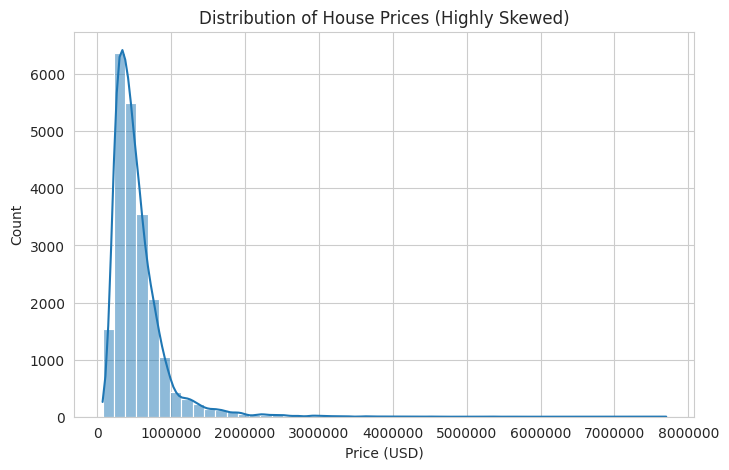

/tmp/ipykernel_3475/2545827677.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='grade', y='price', data=df, ax=axes[1], palette='crest')


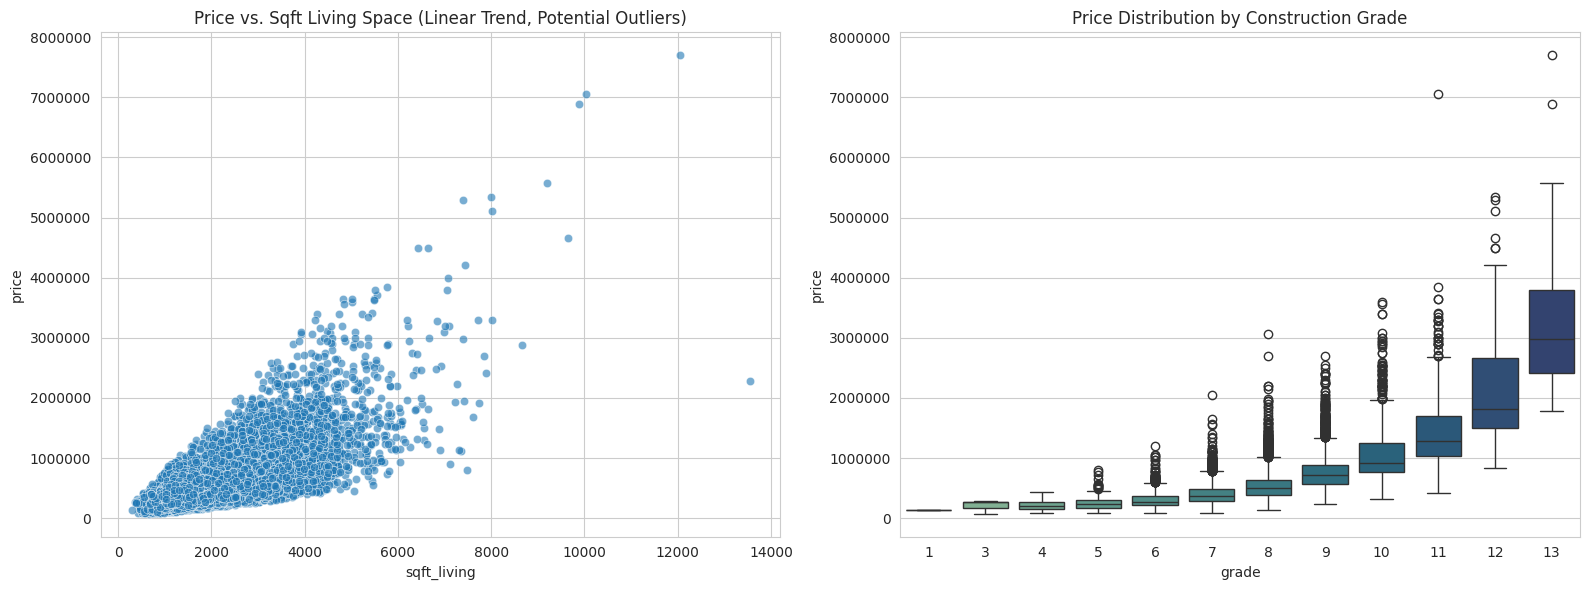

/tmp/ipykernel_3475/2545827677.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='waterfront', y='price', data=df, ax=axes[0], palette='Reds')
/tmp/ipykernel_3475/2545827677.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['No Waterfront (0)', 'Waterfront (1)'])
/tmp/ipykernel_3475/2545827677.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='condition', y='price', data=df, ax=axes[1], palette='Blues')


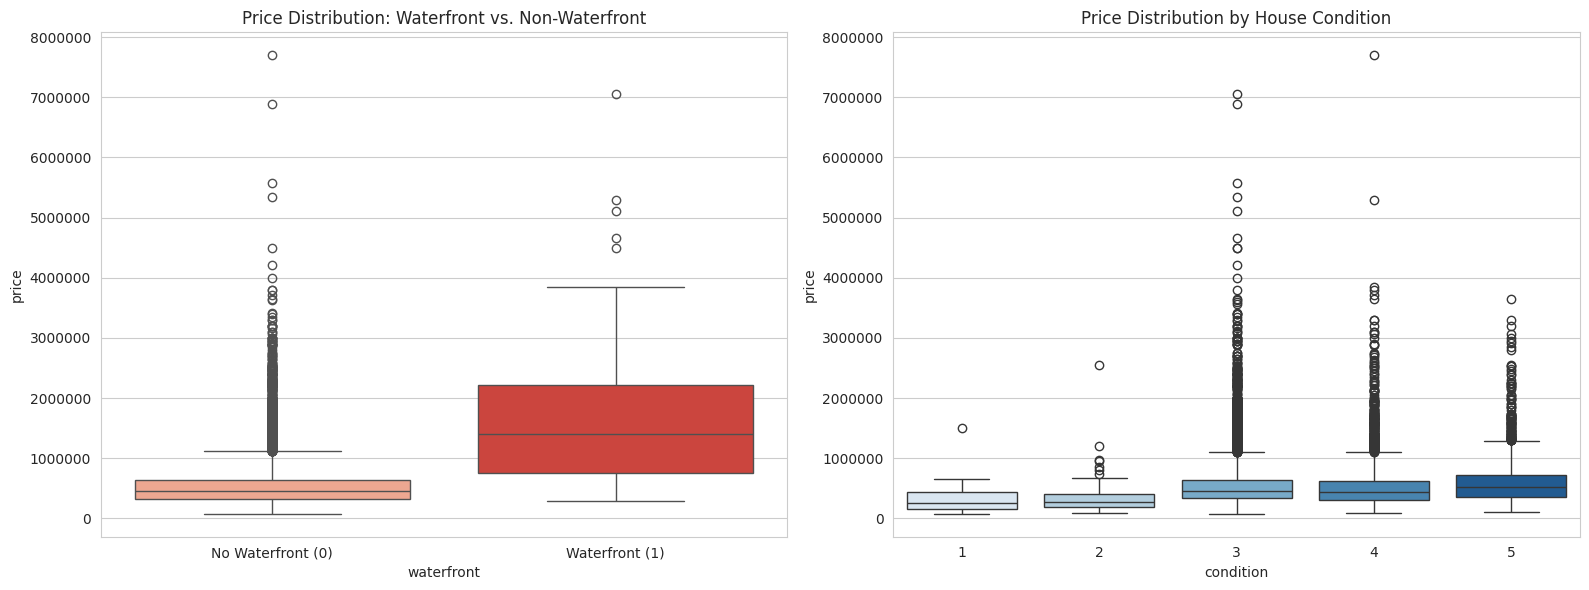


--- 3. Correlation Analysis ---


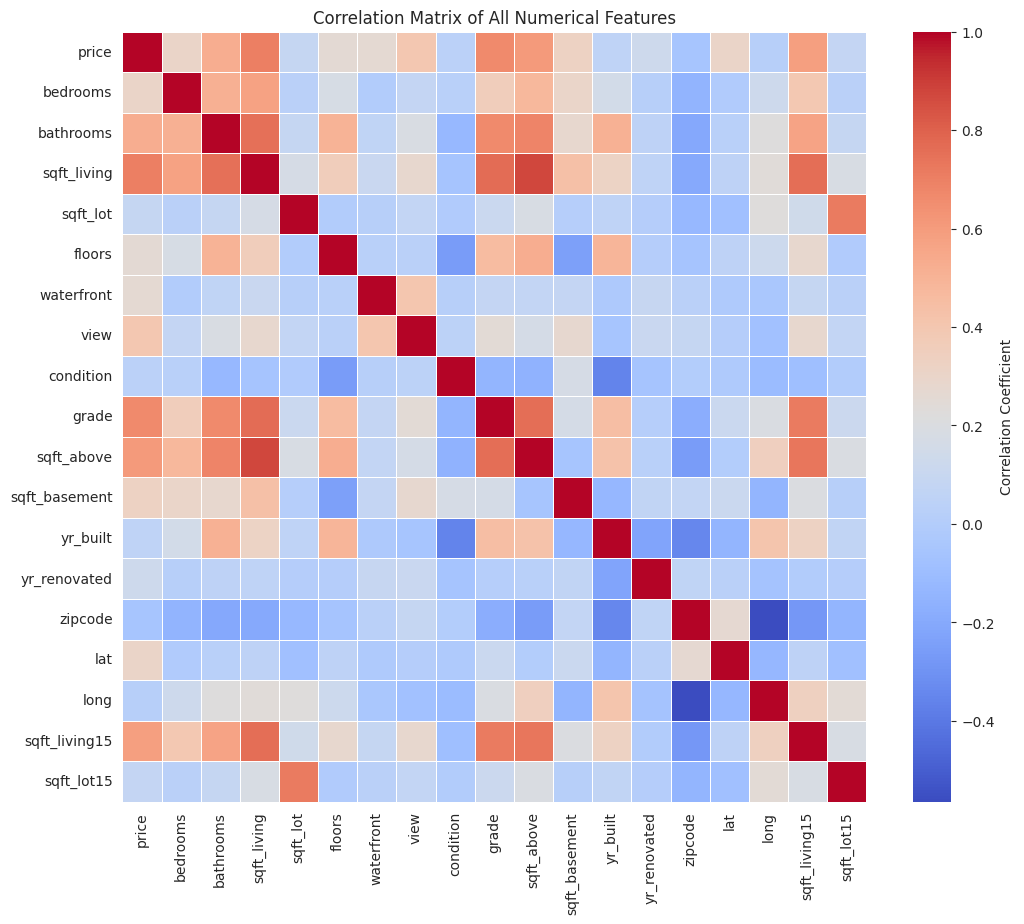


--- Top Features Correlated with Price ---

sqft_living      0.702035
grade            0.667434
sqft_above       0.605567
sqft_living15    0.585379
bathrooms        0.525138
view             0.397293
sqft_basement    0.323816
bedrooms         0.308350
lat              0.307003
waterfront       0.266369
floors           0.256794
yr_renovated     0.126434
sqft_lot         0.089661
sqft_lot15       0.082447
yr_built         0.054012
condition        0.036362
long             0.021626
zipcode         -0.053203
Name: price, dtype: float64


In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100

# 1. INITIAL INSPECTION AND DATA SUMMARY

print("--- 1. Initial Data Inspection ---\n")
print(df.info())

print("\n--- Summary Statistics (Transposed) ---\n")
print(df.describe().T)

print("\n--- Missing Value Check (Null Counts) ---\n")
print(df.isnull().sum())

# 2. UNIVARIATE AND BIVARIATE ANALYSIS

print("\n--- 2. Visualization of Key Features and Relationships ---")

# a) Target variable distribution (price)
plt.figure(figsize=(8, 5))
sns.histplot(df['price'], bins=50, kde=True)
plt.title('Distribution of House Prices (Highly Skewed)')
plt.xlabel('Price (USD)')
plt.ticklabel_format(style='plain', axis='x')
plt.show()

# b) price vs most important predictors (sqft_living and grade)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# scatter plot: price vs sqft_living
sns.scatterplot(x='sqft_living', y='price', data=df, ax=axes[0], alpha=0.6)
axes[0].set_title('Price vs. Sqft Living Space (Linear Trend, Potential Outliers)')
axes[0].ticklabel_format(style='plain', axis='y')

# box plot: price vs grade (ordinal feature)
sns.boxplot(x='grade', y='price', data=df, ax=axes[1], palette='crest')
axes[1].set_title('Price Distribution by Construction Grade')
axes[1].ticklabel_format(style='plain', axis='y')
plt.tight_layout()
plt.show()

# c) price vs binary/categorical Features (waterfront and condition)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# box plot: price vs waterfront
sns.boxplot(x='waterfront', y='price', data=df, ax=axes[0], palette='Reds')
axes[0].set_title('Price Distribution: Waterfront vs. Non-Waterfront')
axes[0].ticklabel_format(style='plain', axis='y')
axes[0].set_xticklabels(['No Waterfront (0)', 'Waterfront (1)'])

# box plot: price vs condition
sns.boxplot(x='condition', y='price', data=df, ax=axes[1], palette='Blues')
axes[1].set_title('Price Distribution by House Condition')
axes[1].ticklabel_format(style='plain', axis='y')

plt.tight_layout()
plt.show()

# 3. CORRELATION ANALYSIS

print("\n--- 3. Correlation Analysis ---")

correlation_matrix = df.drop(columns=['id', 'date']).corr()

# Visualize the correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(
    correlation_matrix,
    annot=False,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=.5,
    cbar_kws={'label': 'Correlation Coefficient'}
)
plt.title('Correlation Matrix of All Numerical Features')
plt.show()

# Display top correlations with the target variable ('price')
print("\n--- Top Features Correlated with Price ---\n")
price_correlations = correlation_matrix['price'].sort_values(ascending=False).drop('price')
print(price_correlations)

In [27]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, QuantileTransformer


print("--- Starting Data Preprocessing ---")

# 1. HANDLE IRRELEVANT COLUMNS
df = df.drop('id', axis=1)
print("1. Dropped 'id' column.")


# 2. DATE AND TIME FEATURE ENGINEERING
df['date'] = pd.to_datetime(df['date'])

# extract sale year and month
df['sale_year'] = df['date'].dt.year
df['sale_month'] = df['date'].dt.month

# calculate house age at the time of sale
df['house_age'] = df['sale_year'] - df['yr_built']

# handle renovation
df['was_renovated'] = np.where(df['yr_renovated'] > 0, 1, 0)
df['renovation_age'] = np.where(df['yr_renovated'] > 0, df['sale_year'] - df['yr_renovated'], 0)

# drop the original date and year columns
df = df.drop(['date', 'yr_built', 'yr_renovated'], axis=1)
print("2. Engineered and dropped date/year columns.")


# 3. HANDLE OUTLIERS (e.g. Extreme Bedrooms)
df = df[df['bedrooms'] < 20]

# handle extremely large sqft_living outliers (e.g top 0.5%)
sqft_living_limit = df['sqft_living'].quantile(0.995)
df = df[df['sqft_living'] < sqft_living_limit]
print("3. Handled extreme outliers in 'bedrooms' and 'sqft_living'.")


# 4. FEATURE ENGINEERING (COMBINING/TRANSFORMING)
df['sqft_lot_ratio'] = df['sqft_lot'] / df['sqft_lot15']
df['sqft_living_ratio'] = df['sqft_living'] / df['sqft_living15']
df = df.drop(['sqft_above', 'sqft_basement'], axis=1)
print("4. Created ratio features and dropped highly correlated columns.")


# 5. LOG TRANSFORMATION OF TARGET VARIABLE
df['log_price'] = np.log1p(df['price'])
df = df.drop('price', axis=1)
print("5. Created 'log_price' as the new target variable.")


# 6. HANDLE CATEGORICAL FEATURES (ZIPCODE)
df = pd.get_dummies(df, columns=['zipcode'], drop_first=True)
print(f"6. Applied One-Hot Encoding to 'zipcode'. Total columns: {df.shape[1]}")


# 7. IDENTIFY FEATURES FOR SCALING
# Separate features (X) and target (y)
y = df['log_price']
X = df.drop('log_price', axis=1)

# Features that benefit from scaling (all continuous/numeric features)
numeric_features = [
    'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
    'view', 'condition', 'grade', 'sqft_living15', 'sqft_lot15',
    'lat', 'long', 'house_age', 'renovation_age',
    'sqft_lot_ratio', 'sqft_living_ratio', 'sale_month', 'sale_year'
]

# 8. FEATURE SCALING (Standardization)
scaler = StandardScaler()

# Fit the scaler only on the selected numeric columns
X[numeric_features] = scaler.fit_transform(X[numeric_features])
print("8. Applied StandardScaler to all continuous numerical features.")

print("\n--- Preprocessing Complete ---")
print(f"Final Features (X) shape: {X.shape}")
print(f"Final Target (y) shape: {y.shape}")
print(f"Final X columns (showing first 5):\n{X.columns[:5].tolist()}...")

--- Starting Data Preprocessing ---
1. Dropped 'id' column.
2. Engineered and dropped date/year columns.
3. Handled extreme outliers in 'bedrooms' and 'sqft_living'.
4. Created ratio features and dropped highly correlated columns.
5. Created 'log_price' as the new target variable.
6. Applied One-Hot Encoding to 'zipcode'. Total columns: 90
8. Applied StandardScaler to all continuous numerical features.

--- Preprocessing Complete ---
Final Features (X) shape: (21503, 89)
Final Target (y) shape: (21503,)
Final X columns (showing first 5):
['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors']...


In [28]:
# 9. SPLIT DATA

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\n--- Data Split Complete ---")
print(f"Training set size (X_train): {X_train.shape}")
print(f"Validation set size (X_val): {X_val.shape}")


--- Data Split Complete ---
Training set size (X_train): (17202, 89)
Validation set size (X_val): (4301, 89)


In [29]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score

# 1. Model Selection and Instantiation
ridge_model = Ridge(alpha=1.0, random_state=42)
print("1. Selected and instantiated Ridge Regression model.")

# 2. Model Training
ridge_model.fit(X_train, y_train)
print("2. Model training complete on X_train and y_train.")

# 3. Initial Prediction
y_pred_log = ridge_model.predict(X_val)
print("3. Predictions generated on the validation set.")


1. Selected and instantiated Ridge Regression model.
2. Model training complete on X_train and y_train.
3. Predictions generated on the validation set.


1. Predictions and actual values transformed back to original price scale.

--- Model Performance Metrics (Original Price Scale) ---
R-squared (R²): 0.8698
Root Mean Squared Error (RMSE): $115,650.49
Mean Absolute Error (MAE): $70,164.81

--- 3. Interpretation of Model Coefficients (Feature Importance) ---
Top 10 Most Influential Features (Coefficients in Scaled Units):
               Coefficient
Feature                   
zipcode_98039     0.814665
zipcode_98004     0.700696
zipcode_98112     0.573008
zipcode_98109     0.513976
zipcode_98040     0.506811
waterfront        0.490621
zipcode_98102     0.487473
zipcode_98119     0.483934
zipcode_98105     0.436250
zipcode_98122     0.368076


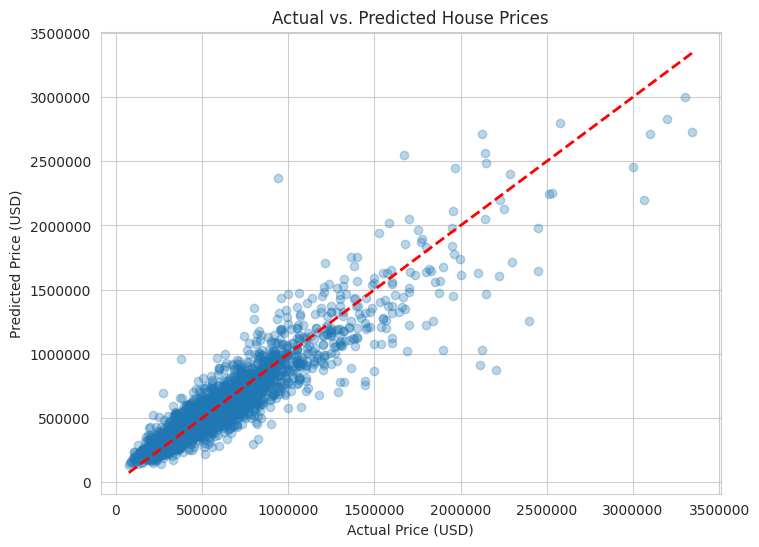

In [31]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# 1. Inverse Transform Predictions and Actuals
y_pred = np.expm1(y_pred_log)

# Convert actual log prices (y_val) back to original price scale (USD)
y_actual = np.expm1(y_val)

print("1. Predictions and actual values transformed back to original price scale.")

# 2. Calculate Regression Metrics

rmse = np.sqrt(mean_squared_error(y_actual, y_pred))

mae = mean_absolute_error(y_actual, y_pred)

r2 = r2_score(y_actual, y_pred)

print("\n--- Model Performance Metrics (Original Price Scale) ---")
print(f"R-squared (R²): {r2:.4f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:,.2f}")
print(f"Mean Absolute Error (MAE): ${mae:,.2f}")

# 3. Interpretation (Model Coefficients for Linear Models)

print("\n--- 3. Interpretation of Model Coefficients (Feature Importance) ---")
features = X_val.columns
coefficients = ridge_model.coef_
coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': coefficients
})

coef_df['Absolute_Coefficient'] = np.abs(coef_df['Coefficient'])
top_10_features = coef_df.sort_values(by='Absolute_Coefficient', ascending=False).head(10)

print("Top 10 Most Influential Features (Coefficients in Scaled Units):")
print(top_10_features.drop(columns=['Absolute_Coefficient']).set_index('Feature'))

plt.figure(figsize=(8, 6))
plt.scatter(y_actual, y_pred, alpha=0.3)
plt.plot([y_actual.min(), y_actual.max()], [y_actual.min(), y_actual.max()], 'r--', lw=2)
plt.xlabel('Actual Price (USD)')
plt.ylabel('Predicted Price (USD)')
plt.title('Actual vs. Predicted House Prices')
plt.ticklabel_format(style='plain', axis='both')
plt.show()